<a href="https://colab.research.google.com/github/OlorteguiKevin/lab10/blob/develop/Lab10_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

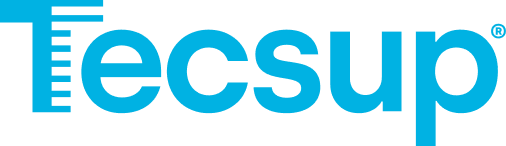

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 10

## Integrantes:
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

1. Con base de la información de la base de datos ‘vehículos’ la cual contiene información sobre diferentes modelos con las características más importantes que los definen, haga lo siguiente:

a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las variables numéricas y dumización para las variables categóricas. Además, elimine las variables ‘fabricante’, ‘modelo’, ‘transmision’, ‘traccion’, ‘clase’, ‘combustible’ y ‘consumo’.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cargar los datos

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Cargar datos desde CSV
try:
    datos = pd.read_csv("/content/drive/MyDrive/V Ciclo/Minería de datos/Semana 10/vehículos.csv", sep=",")
    print("✓ Datos cargados correctamente.")
    print(f"Filas iniciales: {datos.shape[0]}, Columnas iniciales: {datos.shape[1]}")
    print("\nPrimeras filas del dataset:")
    display(datos.head())
except FileNotFoundError:
    print("Error: El archivo CSV no se encontró en la ruta especificada.")

✓ Datos cargados correctamente.
Filas iniciales: 36791, Columnas iniciales: 19

Primeras filas del dataset:


,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


Limpieza básica y tratamiento de datos faltantes

In [41]:
if datos is not None:
    # Verificar valores faltantes en los datos originales
    print("Valores faltantes por columna (inicial):")
    display(datos.isna().sum())

    # Eliminar columnas no necesarias
    columnas_a_eliminar = ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']
    datos_limpios = datos.drop(columns=columnas_a_eliminar, errors='ignore')
    print(f"\nColumnas eliminadas: {columnas_a_eliminar}")

    # Eliminar filas con CUALQUIER valor faltante
    datos_limpios = datos_limpios.dropna(how='any')
    print(f"\nDatos después de eliminar filas con NaN: {datos_limpios.shape[0]} filas, {datos_limpios.shape[1]} columnas")

    # Verificar que no queden NaN después de la eliminación
    print("\nValores faltantes después de dropna():")
    display(datos_limpios.isna().sum())
else:
    print("Saltando módulo 2: Datos no cargados.")

Valores faltantes por columna (inicial):


,0
fabricante,0
modelo,0
year,0
desplazamiento,2
cilindros,3
transmision,2
traccion,789
clase,0
combustible,0
consumo,0



Columnas eliminadas: ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']

Datos después de eliminar filas con NaN: 36788 filas, 12 columnas

Valores faltantes después de dropna():


,0
year,0
desplazamiento,0
cilindros,0
co2,0
clase_tipo,0
traccion_tipo,0
transmision_tipo,0
combustible_tipo,0
tamano_motor_tipo,0
consumo_tipo,0


Separación de variables y tratamiento de Outliers (Univariado con IQR)

In [42]:
if datos is not None and not datos_limpios.empty:
    # Separar variables numéricas y categóricas
    datos_numericos = datos_limpios.select_dtypes(include=['int64', 'float64'])
    datos_categoricos = datos_limpios.select_dtypes(include=['object', 'category'])
    print(f"Variables numéricas identificadas: {list(datos_numericos.columns)}")
    print(f"Variables categóricas identificadas: {list(datos_categoricos.columns)}")

    # Tratamiento de Outliers (Univariado con IQR) en datos numéricos
    if not datos_numericos.empty:
        print("\nIniciando tratamiento de Outliers (IQR) en variables numéricas...")
        Q1 = datos_numericos.quantile(0.25)
        Q3 = datos_numericos.quantile(0.75)
        IQR = Q3 - Q1

        # Definir límites
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Crear una máscara para identificar outliers
        outlier_condition = ((datos_numericos < limite_inferior) | (datos_numericos > limite_superior)).any(axis=1)
        num_outliers_filas = outlier_condition.sum()
        print(f"Filas identificadas con al menos un outlier (basado en IQR): {num_outliers_filas}")

Variables numéricas identificadas: ['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
Variables categóricas identificadas: ['clase_tipo', 'traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

Iniciando tratamiento de Outliers (IQR) en variables numéricas...
Filas identificadas con al menos un outlier (basado en IQR): 1924


Reemplazamos los outliers con la mediana (esto modifica los datos numéricos 'in place' o en una copia)

In [48]:
# Separación de variables y tratamiento de Outliers (Univariado con IQR)
if datos is not None and not datos_limpios.empty:
    # Separar variables numéricas y categóricas
    datos_numericos = datos_limpios.select_dtypes(include=['int64', 'float64'])
    datos_categoricos = datos_limpios.select_dtypes(include=['object', 'category'])
    print(f"Variables numéricas identificadas: {list(datos_numericos.columns)}")
    print(f"Variables categóricas identificadas: {list(datos_categoricos.columns)}")

    # Tratamiento de Outliers (Univariado con IQR) en datos numéricos
    if not datos_numericos.empty:
        print("\nIniciando tratamiento de Outliers (IQR) en variables numéricas...")
        Q1 = datos_numericos.quantile(0.25)
        Q3 = datos_numericos.quantile(0.75)
        IQR = Q3 - Q1

        # Definir límites
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Crear una máscara para identificar outliers
        outlier_condition = ((datos_numericos < limite_inferior) | (datos_numericos > limite_superior)).any(axis=1)
        num_outliers_filas = outlier_condition.sum()
        print(f"Filas identificadas con al menos un outlier (basado en IQR): {num_outliers_filas}")

        # Reemplazamos los outliers con la mediana (esto modifica los datos numéricos 'in place' o en una copia)
        datos_numericos_tratados = datos_numericos.copy() # Trabajar con una copia
        print("Reemplazando outliers con la mediana...")
        for col in datos_numericos_tratados.columns:
            median = datos_numericos_tratados[col].median()
            col_outlier_condition = (datos_numericos_tratados[col] < limite_inferior[col]) | (datos_numericos_tratados[col] > limite_superior[col])
            num_replaced = col_outlier_condition.sum()
            if num_replaced > 0:
                datos_numericos_tratados.loc[col_outlier_condition, col] = median
                print(f"- {num_replaced} outliers reemplazados en '{col}' con la mediana ({median})")

        datos_categoricos_tratados = datos_categoricos.copy() # No se modifica por el tratamiento de outliers numéricos

        print("✓ Tratamiento de Outliers univariado completado.")

    else:
        datos_numericos_tratados = pd.DataFrame()
        datos_categoricos_tratados = datos_categoricos.copy()
        print("No hay variables numéricas para tratar outliers.")

else:
    datos_numericos_tratados = pd.DataFrame()
    datos_categoricos_tratados = pd.DataFrame()
    print("Saltando módulo 3: Datos limpios no disponibles o vacíos.")

Variables numéricas identificadas: ['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
Variables categóricas identificadas: ['clase_tipo', 'traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

Iniciando tratamiento de Outliers (IQR) en variables numéricas...
Filas identificadas con al menos un outlier (basado en IQR): 1924
Reemplazando outliers con la mediana...
- 43 outliers reemplazados en 'desplazamiento' con la mediana (3.0)
- 735 outliers reemplazados en 'cilindros' con la mediana (6.0)
- 232 outliers reemplazados en 'co2' con la mediana (466.0)
- 1392 outliers reemplazados en 'consumo_litros_milla' con la mediana (0.1992321052631579)
✓ Tratamiento de Outliers univariado completado.


In [49]:
# 5. Escalamiento de Datos Numéricos
# Usa los datos numéricos después del tratamiento de outliers (datos_numericos_tratados)
if not datos_numericos_tratados.empty:
    print("\nIniciando escalamiento de variables numéricas (StandardScaler)...")
    scaler = StandardScaler()
    datos_numericos_escalados = scaler.fit_transform(datos_numericos_tratados)
    # Convertir el array de NumPy resultante de vuelta a un DataFrame para mantener nombres de columnas
    datos_numericos_escalados = pd.DataFrame(datos_numericos_escalados, columns=datos_numericos_tratados.columns, index=datos_numericos_tratados.index)
    print("✓ Escalamiento completado.")
    print("\nPrimeras filas de datos numéricos escalados:")
    display(datos_numericos_escalados.head())
else:
    datos_numericos_escalados = pd.DataFrame(index=datos_limpios.index) # Asegurarse de tener un DataFrame vacío con el índice correcto si no hay numéricas
    print("No hay variables numéricas para escalar.")




Iniciando escalamiento de variables numéricas (StandardScaler)...
✓ Escalamiento completado.

Primeras filas de datos numéricos escalados:


,year,desplazamiento,cilindros,co2,consumo_litros_milla
0,-1.618341,-0.604388,-1.061339,0.460121,0.631160
1,-1.618341,0.655056,0.237721,1.886390,2.257353
2,-1.521947,-0.604388,-1.061339,0.749832,0.961480
3,-1.521947,0.655056,0.237721,1.886390,2.257353
4,-1.329157,0.358716,0.237721,0.749832,0.961480


In [50]:

# 6. Dumización de Variables Categóricas
# Usa los datos categóricos después de haberlos separado (datos_categoricos_tratados)
if not datos_categoricos_tratados.empty:
    print("\nIniciando dumización de variables categóricas (pd.get_dummies)...")
    # drop_first=True evita la multicolinealidad
    datos_categoricos_dummies = pd.get_dummies(datos_categoricos_tratados, drop_first=True)
    print("✓ Dumización completada.")
    print("\nPrimeras filas de datos categóricos dumizados:")
    display(datos_categoricos_dummies.head())
else:
    datos_categoricos_dummies = pd.DataFrame(index=datos_limpios.index) # Asegurarse de tener un DataFrame vacío con el índice correcto si no hay categóricas
    print("No hay variables categóricas para dumizar.")



Iniciando dumización de variables categóricas (pd.get_dummies)...
✓ Dumización completada.

Primeras filas de datos categóricos dumizados:


,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,clase_tipo_Furgoneta,clase_tipo_Vehículos Especiales,traccion_tipo_dos,transmision_tipo_Manual,combustible_tipo_Normal,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,False,False,False,False,False,False,True,True,False,True,...,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,False,True,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,False,False,True,True,False,True,...,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,True,False,True,...,False,False,False,False,True,False,False,False,True,False
4,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:

# Combinar los DataFrames preprocesados
# Asegurarse de que los índices coincidan al concatenar
datos_preprocesados = pd.concat([datos_numericos_escalados, datos_categoricos_dummies], axis=1)

print("\n--- Preprocesamiento completo para el requisito 'a' ---")
print(f"DataFrame final después de escalamiento y dumización: {datos_preprocesados.shape[0]} filas, {datos_preprocesados.shape[1]} columnas")
display(datos_preprocesados.head())

# Verificar si hay algún NaN remanente (no debería haber después de dropna)
print("\nVerificando valores faltantes en el DataFrame final preprocesado:")
display(datos_preprocesados.isna().sum())


--- Preprocesamiento completo para el requisito 'a' ---
DataFrame final después de escalamiento y dumización: 36788 filas, 29 columnas


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,-1.618341,-0.604388,-1.061339,0.460121,0.631160,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,-1.618341,0.655056,0.237721,1.886390,2.257353,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,-1.521947,-0.604388,-1.061339,0.749832,0.961480,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,-1.521947,0.655056,0.237721,1.886390,2.257353,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,-1.329157,0.358716,0.237721,0.749832,0.961480,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False



Verificando valores faltantes en el DataFrame final preprocesado:


,0
year,0
desplazamiento,0
cilindros,0
co2,0
consumo_litros_milla,0
clase_tipo_Coche Familiar,0
clase_tipo_Coches Grandes,0
clase_tipo_Coches Medianos,0
clase_tipo_Coches pequeños,0
clase_tipo_Deportivos,0


b. Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el
método del codo para determinar la cantidad de clusters adecuados. Compare los
conglomerados formados y comente sobre las características que definen a estos.


--- Iniciando Análisis de Conglomerados k-means ---
Calculando WCSS para diferentes números de clústeres (Método del Codo)...
Graficando el Método del Codo...


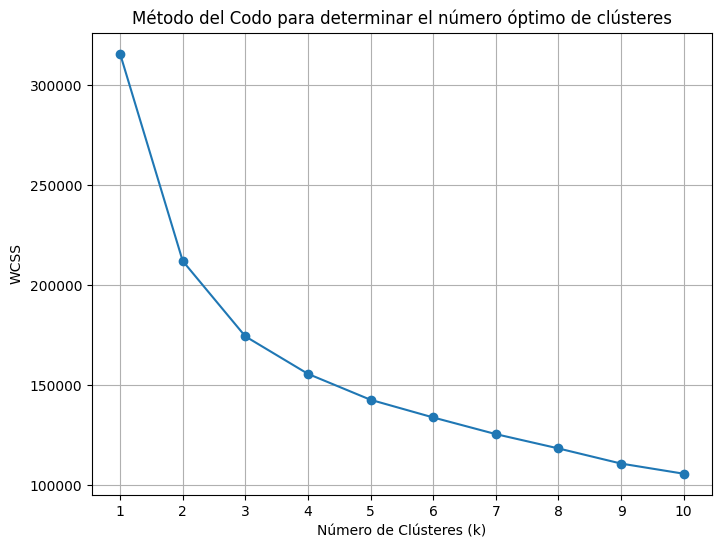


Observe el gráfico para identificar el 'codo', que sugiere el número óptimo de clústeres.
El codo es el punto donde la disminución de WCSS comienza a aplanarse.

Seleccionado 3 clústeres para el análisis final (ajusta si es necesario según el gráfico).


In [52]:
# Asegurarnos de que tenemos datos para trabajar
if datos_preprocesados.empty:
    print("El DataFrame preprocesado está vacío. No se puede realizar el análisis de conglomerados.")
else:
    print("\n--- Iniciando Análisis de Conglomerados k-means ---")

    # 1. Método del Codo para determinar el número óptimo de clústeres
    # Iremos probando diferentes números de clústeres (k)
    # Calcularemos la suma de los cuadrados de las distancias dentro de los clústeres (WCSS - Within-Cluster Sum of Squares)
    wcss = []
    rango_k = range(1, 11) # Puedes ajustar este rango si lo necesitas

    print("Calculando WCSS para diferentes números de clústeres (Método del Codo)...")
    for k in rango_k:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10) # n_init para evitar advertencias
        kmeans.fit(datos_preprocesados)
        wcss.append(kmeans.inertia_) # inertia_ es la WCSS

    # Graficar el Método del Codo
    print("Graficando el Método del Codo...")
    plt.figure(figsize=(8, 6))
    plt.plot(rango_k, wcss, marker='o', linestyle='-')
    plt.title('Método del Codo para determinar el número óptimo de clústeres')
    plt.xlabel('Número de Clústeres (k)')
    plt.ylabel('WCSS')
    plt.xticks(rango_k)
    plt.grid(True)
    plt.show()

    print("\nObserve el gráfico para identificar el 'codo', que sugiere el número óptimo de clústeres.")
    print("El codo es el punto donde la disminución de WCSS comienza a aplanarse.")

    # --- Análisis y Comentario (Después de observar el gráfico) ---
    # Basado en la observación del gráfico, selecciona un número de clústeres óptimo (por ejemplo, 3 o 4, dependiendo de tu interpretación)
    # Aquí, por ejemplo, elegiremos k=3 para demostrar. Deberás ajustar esto según tu gráfico.
    numero_clusters_optimo = 3 # <--- **AJUSTA ESTO BASADO EN TU GRÁFICO DEL CODO**

    print(f"\nSeleccionado {numero_clusters_optimo} clústeres para el análisis final (ajusta si es necesario según el gráfico).")



In [53]:
    # 2. Aplicar k-means con el número óptimo de clústeres
    kmeans_final = KMeans(n_clusters=numero_clusters_optimo, init='k-means++', random_state=42, n_init=10)
    kmeans_final.fit(datos_preprocesados)

    # Obtener las etiquetas de clúster para cada punto de datos
    etiquetas_clusters = kmeans_final.labels_

    # Añadir las etiquetas de clúster al DataFrame original (o al preprocesado para análisis)
    # Usaremos el DataFrame preprocesado ya que contiene las variables que usamos para clustering
    datos_con_clusters = datos_preprocesados.copy()
    datos_con_clusters['Cluster'] = etiquetas_clusters

    print(f"\nDataFrame con etiquetas de clúster añadidas:")
    display(datos_con_clusters.head())




DataFrame con etiquetas de clúster añadidas:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo,Cluster
0,-1.618341,-0.604388,-1.061339,0.460121,0.631160,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,0
1,-1.618341,0.655056,0.237721,1.886390,2.257353,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,1
2,-1.521947,-0.604388,-1.061339,0.749832,0.961480,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,0
3,-1.521947,0.655056,0.237721,1.886390,2.257353,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,1
4,-1.329157,0.358716,0.237721,0.749832,0.961480,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,0


In [55]:
    # 3. Comparar y Comentar sobre las características que definen a los conglomerados
    # Para esto, analizaremos las características promedio de cada clúster.
    print("\nAnalizando las características promedio de cada clúster...")
    analisis_clusters = datos_con_clusters.groupby('Cluster').mean()

    print("\nCaracterísticas promedio por clúster:")
    display(analisis_clusters)

    # Interpretación: Observa el DataFrame `analisis_clusters`.
    # Busca las variables cuyas medias difieren significativamente entre los clústeres.
    # Estas diferencias te ayudarán a describir las características distintivas de cada grupo de vehículos.
    # Por ejemplo, un clúster podría tener un promedio alto en variables de rendimiento (como caballos de fuerza o torque),
    # mientras que otro podría tener promedios altos en variables de eficiencia (como consumo).

    print("\n--- Comentarios sobre las características que definen a los conglomerados ---")
    print("Observa la tabla de características promedio por clúster arriba.")
    print(f"Para cada clúster ({', '.join(map(str, analisis_clusters.index))}), identifica las variables con los valores más altos o más bajos en comparación con los otros clústeres.")
    print("Por ejemplo:")
    print("- ¿Qué clúster tiene el promedio más alto de 'caballos_de_fuerza'?")
    print("- ¿Qué clúster tiene el promedio más bajo en variables de tamaño o peso?")
    print("- ¿Cómo se distribuyen las variables binarias dumizadas (como tipo_carroceria_Sedan, etc.) entre los clústeres?")
    print("\nEstos patrones en los promedios de las variables te permitirán describir qué tipo de vehículos tienden a agruparse en cada clúster.")
    print("Por ejemplo, podrías tener un clúster de 'vehículos deportivos de alto rendimiento', otro de 'vehículos compactos y eficientes', etc.")


print("\n--- Análisis de Conglomerados k-means Completado ---")


Analizando las características promedio de cada clúster...

Características promedio por clúster:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.047283,-0.076555,0.079493,-0.016120,0.083325,0.066832,0.075316,0.151045,0.307401,0.154287,...,0.033313,0.164218,0.182357,0.636803,0.004690,0.009725,0.169391,0.651010,0.004690,0.002138
1,-0.145653,1.299111,1.163575,1.240419,1.142349,0.012321,0.060303,0.056196,0.167084,0.163979,...,0.000000,0.002905,0.009817,0.081639,0.672343,0.000000,0.005009,0.061004,0.709606,0.000000
2,0.062450,-0.963681,-1.037587,-0.987273,-1.024882,0.117097,0.011620,0.122704,0.558996,0.114985,...,0.630668,0.344791,0.385584,0.002600,0.000000,0.610434,0.395986,0.005607,0.000000,0.597026



--- Comentarios sobre las características que definen a los conglomerados ---
Observa la tabla de características promedio por clúster arriba.
Para cada clúster (0, 1, 2), identifica las variables con los valores más altos o más bajos en comparación con los otros clústeres.
Por ejemplo:
- ¿Qué clúster tiene el promedio más alto de 'caballos_de_fuerza'?
- ¿Qué clúster tiene el promedio más bajo en variables de tamaño o peso?
- ¿Cómo se distribuyen las variables binarias dumizadas (como tipo_carroceria_Sedan, etc.) entre los clústeres?

Estos patrones en los promedios de las variables te permitirán describir qué tipo de vehículos tienden a agruparse en cada clúster.
Por ejemplo, podrías tener un clúster de 'vehículos deportivos de alto rendimiento', otro de 'vehículos compactos y eficientes', etc.

--- Análisis de Conglomerados k-means Completado ---


from matplotlib import pyplot as plt
_df_0['Cluster'].plot(kind='hist', bins=20, title='Cluster')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['year'].plot(kind='hist', bins=20, title='year')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Cluster']
  ys = series['consumo_litros_milla']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('Cluster', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Cluster')
_ = plt.ylabel('consumo_litros_milla')

from matplotlib import pyplot as plt
_df_12['Cluster'].plot(kind='line', figsize=(8, 4), title='Cluster')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['year'].plot(kind='line', figsize=(8, 4), title='year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['desplazamiento'].plot(kind='line', figsize=(8, 4), title='desplazamiento')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['cilindros'].plot(kind='line', figsize=(8, 4), title='cilindros')
plt.gca().spines[['top', 'right']].set_visible(False)

c. Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos. También, calcule las principales medidas de evaluación externa tomando una cantidad de clusters de 8 y de referencia a la variable ‘clase_tipo’.

In [56]:
# Resolución del apartado 'c': Evaluación de Conglomerados

from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.cluster import KMeans # Necesario si no lo importaste antes en este script
import pandas as pd # Necesario si no lo importaste antes

# Asegurarnos de que tenemos datos preprocesados y el DataFrame original (para obtener 'clase_tipo')
if datos_preprocesados.empty or datos_limpios.empty: # Usamos datos_limpios para obtener 'clase_tipo'
    print("Los DataFrames necesarios (preprocesados o limpios) no están disponibles. No se puede realizar la evaluación.")
else:
    print("\n--- Iniciando Evaluación de Conglomerados ---")

    # --- Medidas de Evaluación Interna ---
    # Usaremos el número óptimo de clústeres que determinaste en el apartado 'b'
    # Asegúrate de que 'numero_clusters_optimo' está definido y es el número de clústeres con el que aplicaste k-means en 'b'.
    # Si no estás seguro, puedes volver a aplicar k-means aquí con ese número.
    # Para fines de demostración, asumimos que 'numero_clusters_optimo' ya está definido.

    if 'kmeans_final' not in locals():
        print("El modelo k-means final no está disponible. Aplicando k-means con el número óptimo de clústeres...")
        # Aquí necesitas definir numero_clusters_optimo si no lo tienes de antes
        # numero_clusters_optimo = X # <--- Define tu número óptimo de clústeres aquí si es necesario
        if 'numero_clusters_optimo' not in locals():
             print("Error: La variable 'numero_clusters_optimo' no está definida. Por favor, define el número óptimo de clústeres antes de ejecutar esta sección.")
        else:
            kmeans_final = KMeans(n_clusters=numero_clusters_optimo, init='k-means++', random_state=42, n_init=10)
            kmeans_final.fit(datos_preprocesados)
            etiquetas_clusters = kmeans_final.labels_
            print(f"k-means aplicado con {numero_clusters_optimo} clústeres.")

    else:
        etiquetas_clusters = kmeans_final.labels_ # Usar las etiquetas del k-means aplicado en 'b'
        print(f"Usando las etiquetas del modelo k-means previo con {kmeans_final.n_clusters} clústeres para evaluación interna.")


    print("\nCalculando medidas de evaluación interna (usando el número óptimo de clústeres)...")

    # 1. Coeficiente de Silueta
    if len(np.unique(etiquetas_clusters)) > 1: # Silueta requiere al menos 2 clústeres
        silhouette_avg = silhouette_score(datos_preprocesados, etiquetas_clusters)
        print(f"- Coeficiente de Silueta: {silhouette_avg:.4f}")
        print("  Interpretación de Silueta:")
        print("  - Un valor cercano a 1 indica clústeres bien separados y compactos.")
        print("  - Un valor cercano a 0 indica clústeres solapados.")
        print("  - Un valor negativo indica que los puntos pueden haber sido asignados al clúster incorrecto.")
    else:
        print("- Coeficiente de Silueta no calculado: Se requiere al menos 2 clústeres.")





--- Iniciando Evaluación de Conglomerados ---
Usando las etiquetas del modelo k-means previo con 3 clústeres para evaluación interna.

Calculando medidas de evaluación interna (usando el número óptimo de clústeres)...
- Coeficiente de Silueta: 0.2262
  Interpretación de Silueta:
  - Un valor cercano a 1 indica clústeres bien separados y compactos.
  - Un valor cercano a 0 indica clústeres solapados.
  - Un valor negativo indica que los puntos pueden haber sido asignados al clúster incorrecto.


In [57]:
    # 2. Índice de Davies-Bouldin
    # Davies-Bouldin también requiere al menos 2 clústeres
    if len(np.unique(etiquetas_clusters)) > 1:
         davies_bouldin_avg = davies_bouldin_score(datos_preprocesados, etiquetas_clusters)
         print(f"- Índice de Davies-Bouldin: {davies_bouldin_avg:.4f}")
         print("  Interpretación de Davies-Bouldin:")
         print("  - Un valor más bajo indica un mejor agrupamiento (clústeres más compactos y más separados).")
         print("  - El valor mínimo es 0.")
    else:
         print("- Índice de Davies-Bouldin no calculado: Se requiere al menos 2 clústeres.")

    print("\n--- Evaluación Interna Completada ---")

    # --- Medidas de Evaluación Externa ---
    # Para la evaluación externa, usaremos 8 clústeres y la variable 'clase_tipo' como referencia.
    num_clusters_externa = 8
    referencia_externa = datos_limpios['clase_tipo'] # Usamos datos_limpios porque conserva 'clase_tipo' antes de eliminarla en 'a'

    print(f"\nCalculando medidas de evaluación externa (con {num_clusters_externa} clústeres y 'clase_tipo' como referencia)...")

    # Asegurarse de que el índice de los datos preprocesados y la referencia coinciden
    if not datos_preprocesados.index.equals(referencia_externa.index):
        print("Advertencia: Los índices del DataFrame preprocesado y la variable de referencia ('clase_tipo') no coinciden. Asegúrate de que provienen de los mismos datos después de limpiar filas con NaN.")
        # Intentar alinear los datos si es posible (puede ser necesario un merge o join dependiendo de cómo se manejó el dropna)
        # Para simplicidad aquí, asumimos que los índices coinciden si se usó dropna en los datos originales antes de separar.
        # Si no coinciden, necesitarás ajustar cómo se obtiene la referencia_externa.

    # Aplicar k-means con 8 clústeres
    kmeans_externa = KMeans(n_clusters=num_clusters_externa, init='k-means++', random_state=42, n_init=10)
    kmeans_externa.fit(datos_preprocesados)
    etiquetas_clusters_externa = kmeans_externa.labels_

    # 1. Índice de Rand Ajustado (ARI)
    # ARI requiere que las etiquetas de referencia también sean numéricas o consistentes
    # pd.factorize convierte categorías a factores numéricos
    etiquetas_referencia_factorizadas, _ = pd.factorize(referencia_externa)

    ari_score = adjusted_rand_score(etiquetas_referencia_factorizadas, etiquetas_clusters_externa)
    print(f"- Índice de Rand Ajustado (ARI): {ari_score:.4f}")
    print("  Interpretación de ARI:")
    print("  - Un valor cercano a 1 indica un alto acuerdo entre los clústeres formados y las clases de referencia.")
    print("  - Un valor cercano a 0 indica un acuerdo similar al azar.")
    print("  - Valores negativos indican un acuerdo menor al esperado por azar.")


    print("\n--- Evaluación Externa Completada ---")

print("\n--- Evaluación de Conglomerados Completada ---")

- Índice de Davies-Bouldin: 1.5968
  Interpretación de Davies-Bouldin:
  - Un valor más bajo indica un mejor agrupamiento (clústeres más compactos y más separados).
  - El valor mínimo es 0.

--- Evaluación Interna Completada ---

Calculando medidas de evaluación externa (con 8 clústeres y 'clase_tipo' como referencia)...
- Índice de Rand Ajustado (ARI): 0.0654
  Interpretación de ARI:
  - Un valor cercano a 1 indica un alto acuerdo entre los clústeres formados y las clases de referencia.
  - Un valor cercano a 0 indica un acuerdo similar al azar.
  - Valores negativos indican un acuerdo menor al esperado por azar.

--- Evaluación Externa Completada ---

--- Evaluación de Conglomerados Completada ---
